# Distributions

### Table of Contents
[Distributions](#Distributions)

1. [Required imports](#Required-imports)
2. [Data sources](#Data-sources)
    * [Mounting Google Drive](#Mounting-Google-Drive)
    * [Get DataFrame](#Get-DataFrame)
    * [Sources](#Sources)
    * [Variables](#Variables)
3. [Discrete Distributions](#Discrete-Distributions)
    * [Discrete probability mass function](#Discrete-probability-mass-function)
    * [Example - Discrete distribution histogram](#Example---Discrete-distribution-histogram)
    * [Example - Restaurant Groups - Calculating expected value](#Example---Restaurant-Groups---Calculating-expected-value)
    * [Example - Applying for group size of 4](#Example---Applying-for-group-size-of-4)
4. [Continuous Distribution](#Continuous-Distribution)
    * [Example - Bus wait times](#Example---Bus-wait-times)
    * [Simulating wait times](#Simulating-wait-times)
5. [Binomial Distributions](#Binomial-Distributions)
    * [Example - 10 coin flips](#Example---10-coin-flips)
    * [Binomial probability density](#Binomial-probability-density)
6. [Normal distribution](#Normal-distibution)
    * [Exercise - Amir deals](#Exercise---Amir-deals)
    * [Exercise - Simulating sales under new market conditions](#Exercise---Simulating-sales-under-new-market-conditions)
    * [Which market is better?](#Which-market-is-better?)
7. [Central limit theorem (CLT)](#Central-limit-theorem-(CLT))
    * [Comparison Table](#Comparison-Table)
    * [Exercise - Histogram - Amir's deals num_users](#Exercise---Histogram---Amir's-deals-num_users)
8. [Poisson distribution](#Poisson-distribution)
    * [Definition](#Definition)
    * [Mathematical formula](#Mathematical-formula)
    * [Components](#Components)
    * [Prerequisites](#Prerequisites)
    * [Real world examples](#Real-world-examples)
    * [Simulating and Plotting PMF for $k=0…20$, $\lambda\ = 1-10$](#Simulating-and-Plotting-PMF-for-k=0…20,-λ-=-1-10)
    * [Real Life Example: Call Center Support Ticket Arrivals](#Real-Life-Example:-Call-Center-Support-Ticket-Arrivals)
    * [Exercise: Tracking leading responses](#Exercise:-Tracking-leading-responses)
9. [Exponential distribution](#Exponential-distribution)
    * [Examples: General examples](#Examples:-General-examples)
    * [Expected value of exponential distribution](#Expected-value-of-exponential-distribution)
    * [Example: exponential distribution ($\lambda\ = 0.5$)](#Example:-exponential-distribution-(λ-=-0.5))
    * [Example: exponential distribution ($\lambda\ = 0.5, 1.0, 1.5$)](#Example:-exponential-distribution-(λ-=-0.5,-1.0,-1.5))
    * [Using `expon.cdf`](#Using-expon.cdf)
10. [t-distribution (Student t-distribution)](#t-distribution-(Student-t-distribution))
    * [Definition](#Definition)
    * [Mathematical Representation](#Mathematical-Representation)
    * [Standard distribution vs t-distribution](#Standard-distribution-vs-t-distribution)
    * [t-distribution - degrees of freedom](#t-distribution---degrees-of-freedom)
11. [Log-normal distributions](#Log-normal-distributions)
    * [Probability density](#Probability-density)
    * [Real Life Scenarios](#Real-Life-Scenarios)

## Required imports

In [2]:
from scipy.stats import uniform, binom, norm, poisson, expon, t, lognorm
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data sources

### Get DataFrame

In [3]:
def get_df(file_name: str):
  filepath = Path("..")/"data"/file_name
  return pd.read_csv(filepath, index_col=0)

### Sources

In [4]:
amir_deals = get_df('amir_deals.csv')
world_happiness = get_df('world_happiness.csv')

### Variables

In [5]:
restaurant_groups = pd.DataFrame({
    "group_id": ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    "group_size": [2, 4, 6, 2, 2, 2, 3, 2, 4, 2]
})

## Discrete Distributions

(2026-04-18T14:58:47+01:00Z - AI Generated with Gemini 3 Flash - Thinking)

A **discrete distribution** describes the probabilities of outcomes that are "countable" or distinct.

### Discrete probability mass function

(_2026-04-18T22:08:34+07:00Z - AI Generated with Gemini 3 Flash - Thinking_)

In a discrete probability mass function (PMF), we sum the individual probabilities $P(X = x_i)$ for all possible outcomes in the sample space $S$.

$$\sum_{x_i \in S} P(X = x_i) = 1$$


### Example - Discrete distribution histogram

<Axes: ylabel='Frequency'>

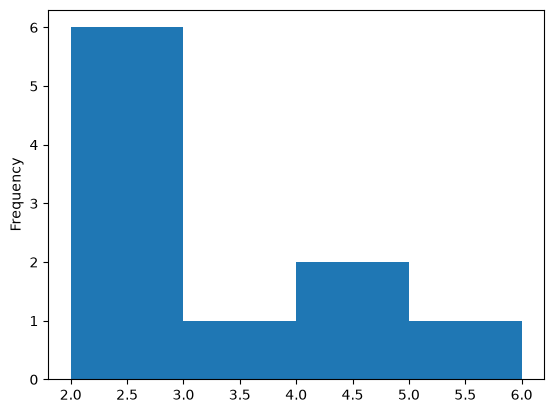

In [6]:
# Create a histogram of restaurant_groups and show plot
restaurant_groups['group_size'].plot(kind='hist', bins=[2, 3, 4, 5, 6])

### Example - Restaurant Groups - Calculating expected value

In [7]:
# Create probability distribution
size_dist = restaurant_groups['group_size'].value_counts() / restaurant_groups.shape[0]
size_dist

group_size
2    0.6
4    0.2
6    0.1
3    0.1
Name: count, dtype: float64

In [8]:
# Reset index and rename columns
size_dist = size_dist.reset_index()
size_dist.columns = ['group_size', 'prob']
size_dist

,group_size,prob
0,2,0.6
1,4,0.2
2,6,0.1
3,3,0.1


In [9]:
# Calculate probability distribution
size_dist['prob_dist'] = size_dist.apply(lambda row: row['group_size'] * row['prob'], axis=1)
size_dist

,group_size,prob,prob_dist
0,2,0.6,1.2
1,4,0.2,0.8
2,6,0.1,0.6
3,3,0.1,0.3


In [10]:
# Calculate expected value
expected_value = np.sum(size_dist['prob_dist'])
expected_value

np.float64(2.9000000000000004)

### Example - Applying for group size of 4

In [11]:
# Subset groups of size 4 or more
groups_4_or_more = size_dist[size_dist['group_size']>=4]
groups_4_or_more

,group_size,prob,prob_dist
1,4,0.2,0.8
2,6,0.1,0.6


In [12]:
# Sum the probabilities of groups_4_or_more
prob_4_or_more = groups_4_or_more['prob'].sum()
prob_4_or_more

np.float64(0.30000000000000004)

## Continuous Distribution



(2026-07-29T16:57:40+07:00Z - AI Generated with Gemini 3.6 Flash (Low))

A continuous distribution describes the probabilities of outcomes for a continuous random variable, where the possible values lie within an uncountable range or continuum (such as any real number within an interval).

Unlike a discrete distribution where probability is assigned to specific individual values, the probability of a continuous random variable taking on any exact specific value is equal to zero:

$$P(X = x) = 0$$

Instead, probabilities are defined over intervals using a Probability Density Function (PDF), denoted as $f(x)$.

The probability that a outcome falls within an interval $[a,b]$ is given by the area under the PDF curve between $a$ and $b$.

$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$

### Example - Bus wait times

#### Probability Density Function (PDF)

$$
f(x) = \begin{cases} \frac{1}{12}, & 0 \le x \le 12 \\ 0, & \text{otherwise} \end{cases}
$$

<br>

#### Probability Calculation for $P(4≤X≤7)$

$$
P(4 \le X \le 7) = (7 - 4) \times \frac{1}{12} = \frac{3}{12} = 0.25
$$

#### Variables

In [13]:
# Bus arrival parameter settings (0 to 12 minutes)
min_wait = 0
max_wait = 12
lower_bound = 4
upper_bound = 7

# colour
colour = {
  'deep_marine_blue': '#0083B0',
  'pale_sky_blue': '#E0F2FE',
  'bright_sky_blue': '#38BDF8'
}


#### Calculations

In [14]:
# Initialize continuous uniform distribution
bus_wait_dist = uniform(loc=min_wait, scale=max_wait - min_wait)

# Calculate specific wait time probabilities
prob_between_4_and_7 = bus_wait_dist.cdf(upper_bound) - bus_wait_dist.cdf(lower_bound)
prob_less_than_3 = bus_wait_dist.cdf(3)
prob_more_than_9 = 1 - bus_wait_dist.cdf(9)

print(f"Probability of waiting between 4 and 7 mins: {prob_between_4_and_7:.2%}")
print(f"Probability of waiting less than 3 mins: {prob_less_than_3:.2%}")
print(f"Probability of waiting more than 9 mins: {prob_more_than_9:.2%}")

Probability of waiting between 4 and 7 mins: 25.00%
Probability of waiting less than 3 mins: 25.00%
Probability of waiting more than 9 mins: 25.00%


#### Continuous Distribution plot

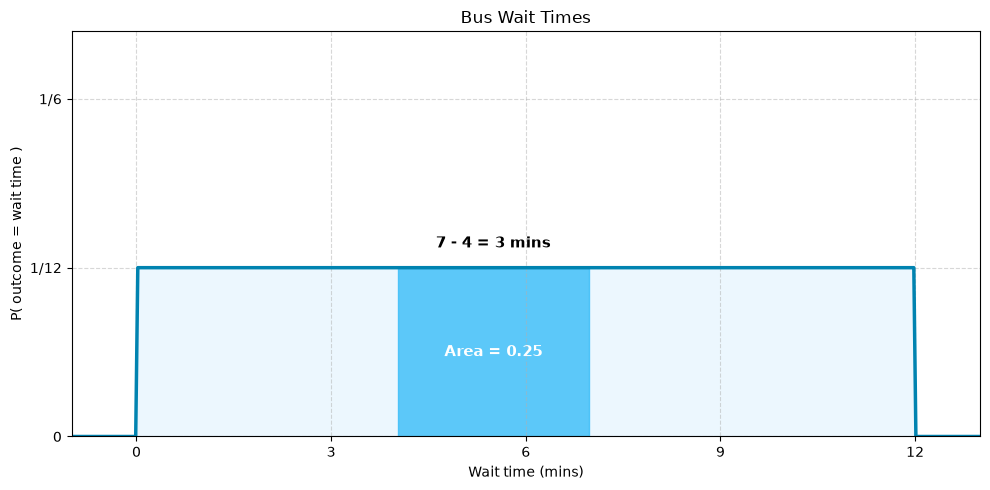

In [15]:
# Generate visual plot
x = np.linspace(-2, 14, 500)
y = bus_wait_dist.pdf(x)

# Note: *figure variable is unused
*figure, axis = plt.subplots(figsize=(10, 5))

# Plot overall PDF curve
axis.plot(x, y, color=colour['deep_marine_blue'], linewidth=2.5, label="PDF f(x) = 1/12")

# Fill base distribution area [0, 12]
axis.fill_between(
    x, y, where=(x >= min_wait) & (x <= max_wait), color=colour['pale_sky_blue'], alpha=0.6
)

# Fill target interval area [4, 7]
axis.fill_between(
    x, y, where=(x >= lower_bound) & (x <= upper_bound), color=colour['bright_sky_blue'], alpha=0.8
)

# Annotate target area height and width
axis.annotate(
    "7 - 4 = 3 mins",
    xy=(5.5, 1 / 12 + 0.01),
    ha="center",
    fontsize=11,
    weight="bold",
)
axis.annotate(
    f"Area = {prob_between_4_and_7:.2f}",
    xy=(5.5, 1 / 24),
    ha="center",
    va="center",
    color="white",
    fontsize=11,
    weight="bold",
)

axis.set_xlim(-1, 13)
axis.set_ylim(0, 1 / 5)
axis.set_xticks([0, 3, 6, 9, 12])
axis.set_yticks([0, 1 / 12, 1 / 6])
axis.set_yticklabels(["0", "1/12", "1/6"])
axis.set_xlabel("Wait time (mins)")
axis.set_ylabel("P( outcome = wait time )")
axis.set_title("Bus Wait Times")
axis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Simulating wait times

In [16]:
# Generate 1000 wait times between 0 and 30 mins
wait_times = uniform.rvs(0, 30, size=1000, random_state=334)
wait_times

array([ 7.144097  ,  0.97455866,  3.72802787,  5.11644319,  8.70602482,
       24.69140099, 23.98012075,  3.19592668, 25.1985306 , 17.89048629,
       24.68695356, 18.27160808, 22.85829011,  0.12929581, 15.67789664,
        2.3262095 , 15.79151771, 21.90473557, 18.25817257, 15.78657023,
       28.74328434,  9.38971275, 17.0010565 ,  0.95433991, 15.96917606,
        2.16395679,  8.903302  , 19.24982156,  6.52414731, 14.10185677,
       27.86973455, 14.38121016, 28.59233824, 13.17550521, 22.96382405,
        2.52904371,  6.2163781 ,  8.40217036,  4.48079914, 28.16365298,
       19.73302715,  3.63959282,  1.74002295,  1.5324219 , 26.97096908,
       29.37490861,  4.71379092,  6.44990488,  6.81999564, 22.81302458,
       12.41563042, 11.14591581,  8.08043184, 29.60574053,  3.24571518,
       19.66709277, 13.38939302, 29.56433707, 24.84697258,  6.249684  ,
       15.07668579,  5.27474477, 27.27430815,  2.42084219, 27.88317515,
        0.81231424,  3.48564273, 19.80738592,  6.11128124, 19.10

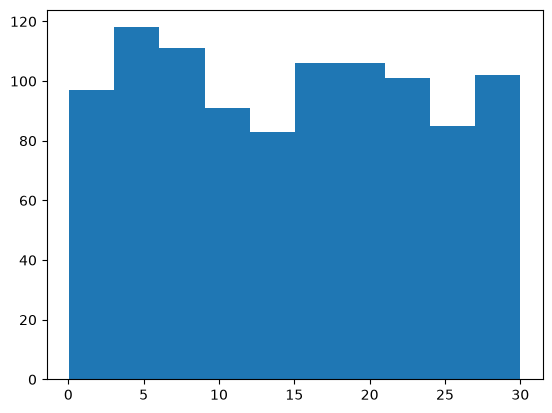

In [17]:
# Create a histogram of simulated times and show plot
plt.hist(wait_times)
plt.show()

## Binomial Distributions

### TL;DR;

Probability distribution of the number of successes in a sequence of independent trials

### Definition

The **binomial distribution** is a discrete probability distribution that models the number of "successes" in a fixed number of independent trials. It is one of the most common ways to analyse scenarios where there are only two possible outcomes.

### Formula

The probability of getting exactly $k$ successes in $n$ trials is calculated using the following formula:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

**Where:**
- $n$: Total number of trials.
- $k$: Number of successes desired.
- $p$: Probability of success on an individual trial.
- $\binom{n}{k}$: The binomial coefficient ("n choose k"), calculated as $\frac{n!}{k!(n-k)!}$.

### Key Properties
- **Mean ($\mu$):** The average number of successes you can expect, calculated as $np$.
- **Variance ($\sigma^2$):** The spread of the data, calculated as $np(1-p)$.
- **Shape:** If $p = 0.5$, the distribution is perfectly symmetrical. If $p$ is very small or very large, the distribution becomes skewed.

### Prerequisites

For a process to follow a binomial distribution, it must meet these four conditions (often remembered by the acronym **BINS**):
1. **Binary:** There are only two possible outcomes for each trial (e.g., Success/Failure, Yes/No, Heads/Tails).
2. **Independent:** The outcome of one trial does not affect the outcome of another.
3. **Number:** The number of trials ($n$) is fixed in advance.
4. **Success probability:** The probability of success ($p$) is the same for every trial.


### Why "Independent"?
If successive events are not independent, the probability of a binary outcome is changed over each successive event. Which cannot be represented by a binomial distribution.

### Example - 10 coin flips

#### Parameters

In [18]:
# Parameters for the binomial distribution
n = 10
p = 0.5
k_values = np.arange(0, n + 1)
pmf_values = binom.pmf(k_values, n, p)

#### Plots

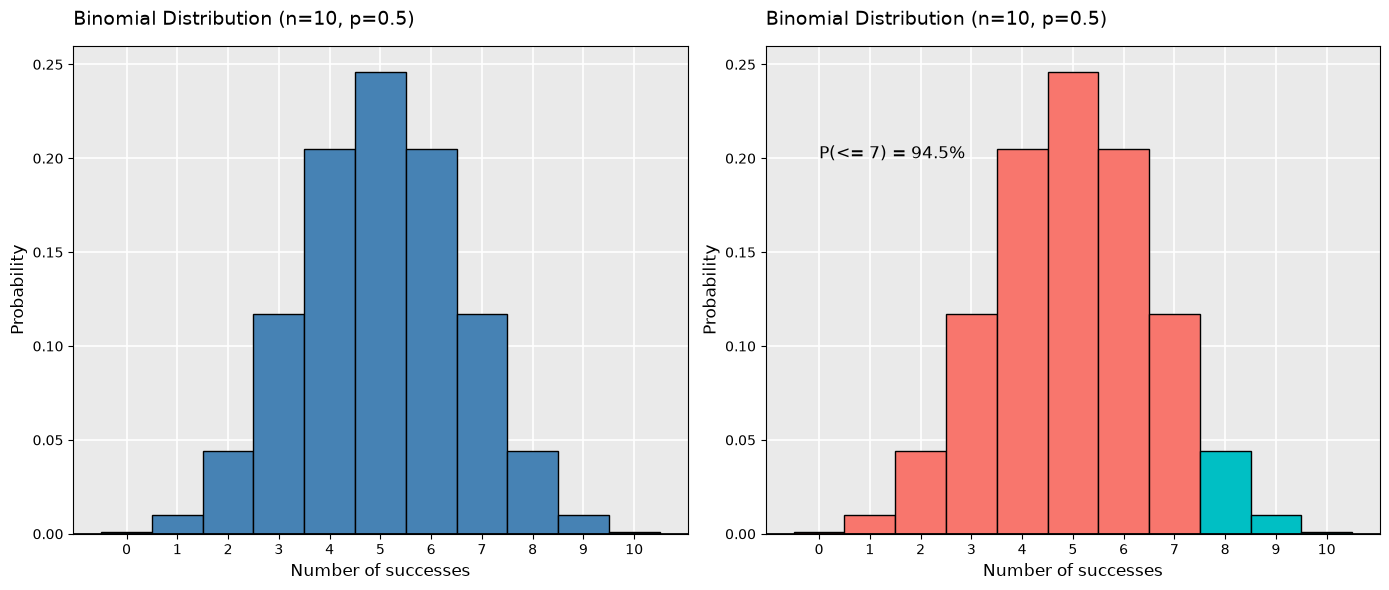

In [19]:
# Setup subplots for both representations
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(14, 6))

# Set ggplot - plot style backgrounds
for axis in (axis1, axis2):
    axis.set_facecolor('#EAEAEA')
    axis.grid(True, color='white', linewidth=1.2)
    axis.set_axisbelow(True)

# ---------------------------------------------------------
# Plot 1: Standard Binomial Distribution (PMF)
# ---------------------------------------------------------
axis1.bar(k_values, pmf_values, color='#4682B4', edgecolor='black', width=1.0, align='center')
axis1.axhline(0, color='black', linewidth=2)
axis1.set_title('Binomial Distribution (n=10, p=0.5)', fontsize=14, loc='left', pad=15)
axis1.set_xlabel('Number of successes', fontsize=12)
axis1.set_ylabel('Probability', fontsize=12)
axis1.set_xticks(k_values)
axis1.set_ylim(0, 0.26)

# ---------------------------------------------------------
# Plot 2: Cumulative Binomial Distribution Highlight (P(X <= 7))
# ---------------------------------------------------------
target_k = 7
prob_le_7 = binom.cdf(target_k, n, p)

# Colors: Coral for k <= 7, Cyan for k > 7
bar_colors = ['#F8766D' if k <= target_k else '#00BFC4' for k in k_values]

axis2.bar(k_values, pmf_values, color=bar_colors, edgecolor='black', width=1.0, align='center')
axis2.axhline(0, color='black', linewidth=2)
axis2.set_title('Binomial Distribution (n=10, p=0.5)', fontsize=14, loc='left', pad=15)
axis2.set_xlabel('Number of successes', fontsize=12)
axis2.set_ylabel('Probability', fontsize=12)
axis2.set_xticks(k_values)
axis2.set_ylim(0, 0.26)

# Annotation for P(<= 7)
axis2.text(0, 0.20, f'P(<= {target_k}) = {prob_le_7 * 100:.1f}%', fontsize=12, fontweight='normal')

plt.tight_layout()
plt.show()

### Binomial probability density

(Uses the formula above)

Presuming that Amir wins 30% of deals. He wants to get an idea of how likely he is to close a certain number of deals each week.

Calculate what the chances are of him closing different numbers of deals using the binomial distribution.

#### Probability density function

In [20]:
# Probability of closing 3 out of 3 deals
prob_3 = binom.pmf(k=3, n=3, p=0.3)
percentage_prob_3 = prob_3 * 100
f"{percentage_prob_3:.2f}%"

'2.70%'

#### Cumulative density function

In [21]:
# Probability of closing <= 1 deal out of 3 deals
prob_less_than_or_equal_1 = binom.cdf(1, 3, 0.3)
f"{prob_less_than_or_equal_1:.2%}"

'78.40%'

In [22]:
# Probability of closing > 1 deal out of 3 deals
prob_greater_than_1 = 1 - binom.cdf(1,3, 0.3)
f"{prob_greater_than_1:.2%}"

'21.60%'

## Normal distibution

(_2026-04-19T12:34:00Z - AI Generated with Gemini 3 Flash - Thinking_)

## Also Known As
- Gaussian distribution
- bell-curve

## Definition
A **Normal Distribution** (also known as a Gaussian distribution) describes a continuous probability distribution for a real-valued random variable. It is defined by two specific parameters:
- **Mean ($\mu$):** This determines the center or "peak" of the bell curve.
- **Standard Deviation ($\sigma$):** This determines the spread or "width" of the curve.
Because $\mu$ and $\sigma$ can be any real numbers (provided $\sigma > 0$), there are an infinite number of possible normal distributions.

## Prerequisites

- **Symmetry and Central Tendency**: the data must exhibit a specific shape and relationship between its measures of center:
	- **Symmetry:** The distribution must be symmetric about the mean.
	- **Equality of Central Measures:** In a perfect normal distribution, the **mean = median = mode**.
	- **Unimodal:** There must be only one peak (one mode).
- **Mean ($\mu$):** represent the location of the peak (center), can be any value along the continuous real number line.
$$\mu \in \mathbb{R}$$
<br>

- **Standard deviation $(\sigma)$** - represents a distance or magnitude of spread, meaning it cannot be negative, and must be a real number
$$\sigma \in \mathbb{R}_{\geq 0} \quad \text{or} \quad \sigma \in \{x \in \mathbb{R} \mid x \geq 0\}$$
<br>

- **The Empirical Rule (68-95-99.7)**
	- For a distribution to be considered normal, the data must be dispersed according to the following probabilities:
		- Approximately **68%** of the data falls within $1\sigma$ of the mean.
		- Approximately **95%** of the data falls within $2\sigma$ of the mean.
		- Approximately **99.7%** of the data falls within $3\sigma$ of the mean.
- **Asymptotic Nature**: the "tail ends" of the distribution must be asymptotic. This means the curve approaches the horizontal axis (the x-axis) but never actually touches or crosses it, extending to infinity in both directions ($-\infty$ to $+\infty$)
- **Continuous Data**: The variable $X$ must be **continuous**. While we often approximate discrete data (like heights measured to the nearest inch) using a normal curve, the mathematical prerequisite is that the variable can take any value within an interval.

### Exercise - Amir deals

#### Histogram - Amir deals

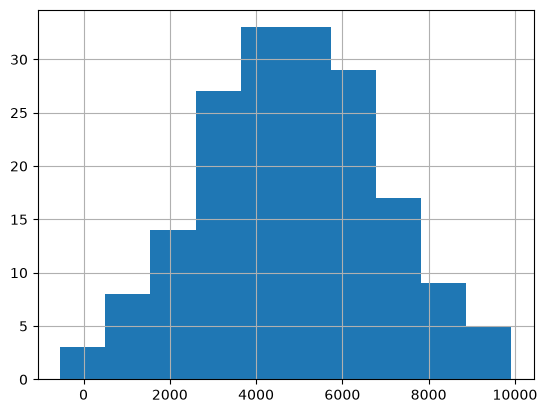

In [23]:
# Histogram of amount with 10 bins and show plot
amir_deals['amount'].hist(bins=10)
plt.show()

#### Probabilities from the normal distribution

- `cdf` - cumulative density function
- `ppf` - percent point function (inverse of `cdf`)




In [24]:
# What's the probability of Amir closing a deal worth less than $7500?
prob_less_7500 = norm.cdf(7500, 5000, 2000)
f"{prob_less_7500:.2%}"

'89.44%'

In [25]:
# What's the probability of Amir closing a deal worth more than $1000?
prob_over_1000 = 1-norm.cdf(1000,5000,2000)
f"{prob_over_1000:.2%}"

'97.72%'

In [26]:
# What's the probability of Amir closing a deal worth between $3000 and $7000?
prob_3000_to_7000 = norm.cdf(7000,5000,2000) - norm.cdf(3000,5000,2000)
f"{prob_3000_to_7000:.2%}"

'68.27%'

In [27]:
# What amount will 25% of Amir's sales be less than?
pct_25 = norm.ppf(.25, 5000, 2000)
pct_25

np.float64(3651.0204996078364)

### Exercise - Simulating sales under new market conditions

The company's financial analyst is predicting that next quarter, the worth of each sale will increase by 20% and the volatility, or standard deviation, of each sale's worth will increase by 30%.

To see what Amir's sales might look like next quarter under these new market conditions, you'll simulate new sales amounts using the normal distribution and store these in the `new_sales` DataFrame, which has already been created for you.

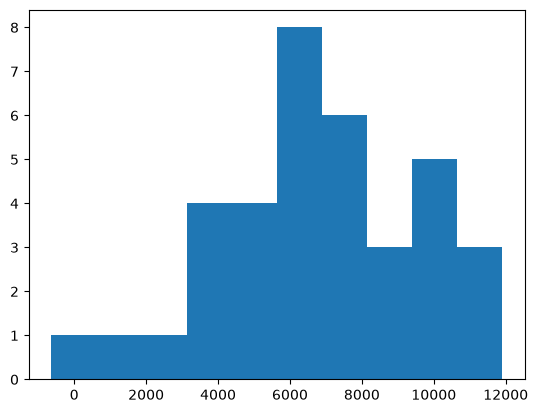

In [28]:
# Calculate new average amount
new_mean = 5000 * 1.2

# Calculate new standard deviation
new_sd = 2000 * 1.3

# Simulate 36 new sales
new_sales = norm.rvs(new_mean, new_sd, 36, random_state=0)

# Create histogram and show
plt.hist(new_sales)
plt.show()

### Which market is better?

The key metric that the company uses to evaluate salespeople is the percent of sales they make over $1000 since the time put into each sale is usually worth a bit more than that, so the higher this metric, the better the salesperson is performing.

Recall that Amir's current sales amounts have a mean of \$5000 and a standard deviation of \$2000, and Amir's predicted amounts in next quarter's market have a mean of \$6000 and a standard deviation of $2600.

#### Question

Based ___only___ on the metric of **percent of sales over $1000**, does Amir perform better in the current market or the predicted market?

#### Working out

Remember that you calculated the percent of sales over $1000 in the current market using

```python
1 - norm.cdf(1000, 5000, 2000)
```

#### Answer

Amir performs about equally in both markets.

## Central limit theorem (CLT)

(_2026-04-19T13:04:08+07:00Z - AI Generated with Gemini 3 Flash - Fast_)

###  Collection of more data

While the **Law of Large Numbers (LLN)** and the **Central Limit Theorem (CLT)** both describe what happens as you collect more data (n→∞), they focus on two different properties of the result.

#### Which distributions does the CLT apply too?

(_2026-04-19T23:14:18+07:00 - AI Generated with Gemini 3 Flash - Fast_)

The beauty — and the reason it is called "Central"—is that the theorem applies to **virtually any distribution**, regardless of its shape, as long as it meets a few specific mathematical criteria.

Whether your starting data is discrete (like dice rolls) or continuous (like the time between raindrops), the **means** of those samples will always march toward a Normal distribution.

### Definition: The Goal - Destination vs. Shape

The easiest way to distinguish them is by asking: **"What am I looking at?"**
- **Law of Large Numbers (LLN):** Focuses on the **accuracy of a single value**. It states that as your sample size grows, the sample mean ($\bar{X}$) will converge to the population mean ($\mu$). It promises that your estimate will eventually hit the "destination."

$$\bar{X}n​→\mu\ as\ n→∞$$
<br>

- **Central Limit Theorem (CLT):** Focuses on the **shape of the error**. It doesn't just say you'll get to the mean; it describes the _way_ the sample means are distributed around that mean while you're getting there. It promises that the "journey" will look like a bell curve.

$$\bar{X}n​≈N(μ,\frac{n}{σ^2}​)$$

### Comparison Table

| Feature                 | Law of Large Numbers (LLN)                                               | Central Limit Theorem (CLT)                                                        |
| ----------------------- | ------------------------------------------------------------------------ | ---------------------------------------------------------------------------------- |
| **Primary Question**    | Where is the sample mean going?                                          | What does the distribution of means look like?                                     |
| **Mathematical Result** | Convergence to a single point (μ).                                       | Convergence to a distribution (Normal).                                            |
| **Key Requirement**     | Finite Mean (μ∈R).                                                       | Finite Mean **and** Finite Variance (σ2<∞).                                        |
| **Analogy**             | Shooting an arrow: The more you practice, the more you hit the bullseye. | Shooting an arrow: The pattern of missed shots around the bullseye forms a circle. |

### Exercise - Histogram - Amir's deals `num_users`

#### Histogram - `num_users`

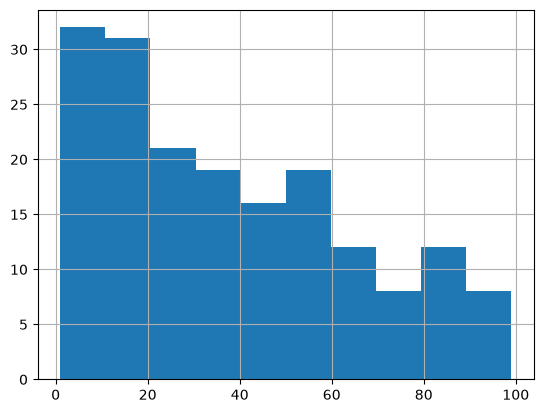

In [29]:
# Create a histogram of num_users and show
num_users = amir_deals['num_users'].hist()
plt.show()

#### Histogram - `sample_means` 1,000 times

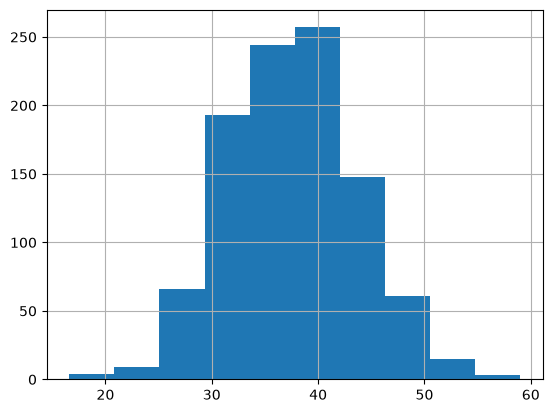

In [30]:
# Set seed to 104
np.random.seed(104)

sample_means = []
# Loop 100 times
for i in range(1000):
  # Take sample of 20 num_users
  samp_20 = amir_deals['num_users'].sample(20, replace=True)
  # Calculate mean of samp_20
  samp_20_mean = np.mean(samp_20)
  # Append samp_20_mean to sample_means
  sample_means.append(samp_20_mean)

# Convert to Series and plot histogram
sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
# Show plot
plt.show()

## Poisson distribution

(_2026-04-20T13:14:21+07:00Z - AI Generated with Gemini 3 Flash - Thinking_)

### Definition

The **Poisson distribution** is a discrete probability distribution that expresses the probability of a given number of events occurring in a **fixed interval of time or space** .

Named after French mathematician Siméon Denis Poisson, it is used when these events occur with a known constant mean rate and independently of the time since the last event.

### Mathematical formula

The probability of observing exactly $k$ events in an interval is given by the formula:

<br>

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

<br>

- **$P(X = k)$** is the probability of $k$ events occurring.
- **$\lambda$** (lambda) is the average number of events per interval (the "expected value").
- **$e$** is Euler's number
- **$k$** is the number of occurrences ($k = 0, 1, 2, \dots$).
- **$k!$** is the factorial of $k$.

### Components

(*2026-04-20T13:48:28+0700*)

Requires the following
- Space or Time component - fixed interval or space
- Number of events
- Probability of each event

### Prerequisites

| Requirement        | Description                                                                  | Why it matters                                                                                                                           |
| ------------------ | ---------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **Discrete Data**  | Data must $\{n\in\mathbb{N}\}$                                               | You cannot have negative events or fractional occurrences (e.g., "1.5 emails").                                                          |
| **Fixed Interval** | Data must be collected over a consistent "exposure" (time, area, or volume). | If you compare "calls per hour" to "calls per day," the model will fail unless you adjust for the interval length.                       |
| **Equidispersion** | The **Mean** must roughly equal the **Variance**.                            | If the variance is much higher than the mean (overdispersion), the Poisson model will underestimate the risk of extreme events.          |
| **Independence**   | The occurrence of one event cannot change the likelihood of another.         | If one event "triggers" another (like a contagious disease or a "buy one, get one" rush), the Poisson model is invalid.                  |
| **Constant Rate**  | The average rate (λ) must be stable across the interval.                     | If the arrival rate changes (e.g., a restaurant busy at lunch but dead at 3 PM), you must split the data into smaller, stable intervals. |

### Real world examples

The Poisson distribution is incredibly useful for modelling scenarios where we look at "arrivals" or "counts":
- **Customer Service:** The number of calls received by a help desk per hour.
- **Radioactive Decay:** The number of particles emitted by a radioactive source in a second.
- **Website Traffic:** The number of users visiting a website per minute.
- **Natural Disasters:** The number of meteorites greater than 1 meter diameter that strike Earth in a year.

### Simulating and Plotting PMF for $k=0…20$, $\lambda\ = 1-10$

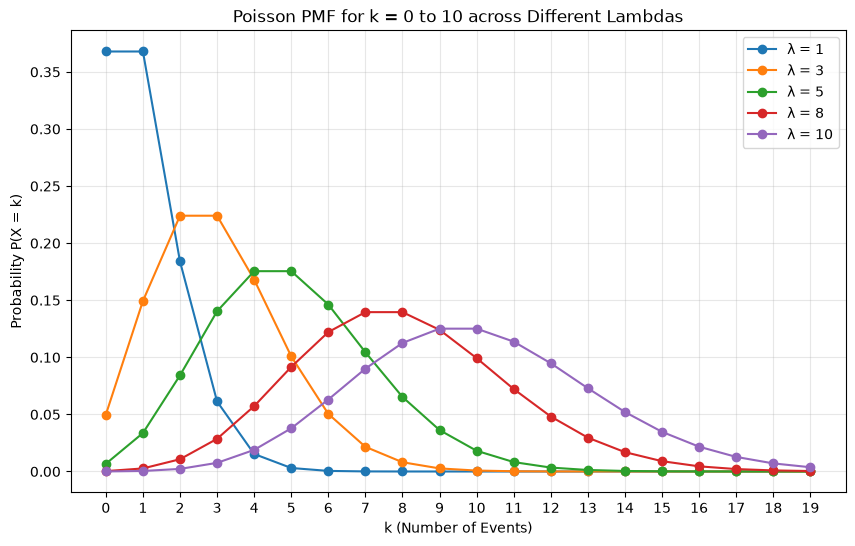

In [31]:
k = np.arange(0, 20)
lambdas = [1, 3, 5, 8, 10]

plt.figure(figsize=(10, 6))

for lam in lambdas:
    # Exact theoretical PMF for k = 0..10
    pmf_values = poisson.pmf(k, lam)
    plt.plot(k, pmf_values, marker="o", linestyle="-", label=f"λ = {lam}")

    # Simulated sampling (10,000 trials truncated to 0..10)
    samples = np.random.poisson(lam=lam, size=10000)
    samples_in_range = samples[samples <= 10]

plt.title("Poisson PMF for k = 0 to 10 across Different Lambdas")
plt.xlabel("k (Number of Events)")
plt.ylabel("Probability P(X = k)")
plt.xticks(k)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Real Life Example: Call Center Support Ticket Arrivals

A customer support center tracks the number of incoming help requests per minute. Traffic varies depending on the time of day:

- Quiet hours (early morning): $λ=1.5$ calls/minute
- Normal hours (midday): $λ=4.0$ calls/minute
- Peak hours (product launch): $λ=7.5$ calls/minute

The management needs to calculate the probability of receiving between $0$ and $10$ calls in any given minute to allocate staff appropriately.

In [32]:
# Operational scenarios (mean arrival rate per minute)
scenarios = {"Quiet Hour": 1.5, "Normal Hour": 4.0, "Peak Hour": 7.5}
k_range = np.arange(0, 11)
print("Call Center Arrival Probabilities (0 to 10 calls/min):")
print(f"{'Calls (k)':<10}" + "".join([f"{name:<15}" for name in scenarios]))
for k in k_range:
    row = f"{k:<10}"
    for name, lam in scenarios.items():
        prob = poisson.pmf(k, lam)
        row += f"{prob:<15.4f}"
    print(row)
# Empirical simulation for staff planning
np.random.seed(42)
for name, lam in scenarios.items():
    simulated_calls = np.random.poisson(lam, size=1000)
    zero_calls_pct = np.mean(simulated_calls == 0) * 100
    exceed_10_pct = np.mean(simulated_calls > 10) * 100
    print(
        f"\n[{name} (λ={lam})]"
        f"\n  Idle minute probability (0 calls): {zero_calls_pct:.1f}%"
        f"\n  Overload minute probability (>10 calls): {exceed_10_pct:.1f}%"
    )

Call Center Arrival Probabilities (0 to 10 calls/min):
Calls (k) Quiet Hour     Normal Hour    Peak Hour      
0         0.2231         0.0183         0.0006         
1         0.3347         0.0733         0.0041         
2         0.2510         0.1465         0.0156         
3         0.1255         0.1954         0.0389         
4         0.0471         0.1954         0.0729         
5         0.0141         0.1563         0.1094         
6         0.0035         0.1042         0.1367         
7         0.0008         0.0595         0.1465         
8         0.0001         0.0298         0.1373         
9         0.0000         0.0132         0.1144         
10        0.0000         0.0053         0.0858         

[Quiet Hour (λ=1.5)]
  Idle minute probability (0 calls): 23.6%
  Overload minute probability (>10 calls): 0.0%

[Normal Hour (λ=4.0)]
  Idle minute probability (0 calls): 2.4%
  Overload minute probability (>10 calls): 0.0%

[Peak Hour (λ=7.5)]
  Idle minute probability 

### Exercise: Tracking leading responses

Your company uses sales software to keep track of new sales leads. It organizes them into a queue so that anyone can follow up on one when they have a bit of free time.

Since the number of lead responses is a countable outcome over a period of time, this scenario corresponds to a Poisson distribution.

On average, Amir responds to $4$ leads each day. In this exercise, you'll calculate probabilities of Amir responding to different numbers of leads.

In [33]:
# Calculate the probability that Amir responds to 5 leads in a day, given that he responds to an average of 4.
prob_5 = poisson.pmf(5,4)
f"{prob_5:.2%}"

'15.63%'

In [34]:
# Amir's coworker responds to an average of 5.5 leads per day. What is the probability that she answers 5 leads in a day?
prob_coworker = poisson.pmf(5, 5.5)
f"{prob_coworker:.2%}"

'17.14%'

In [35]:
# What's the probability that Amir responds to 2 or fewer leads in a day?
prob_2_or_less = poisson.cdf(2,4)
f"{prob_2_or_less:.2%}"

'23.81%'

In [36]:
# What's the probability that Amir responds to more than 10 leads in a day?
prob_over_10 = 1 - poisson.cdf(10,4)
f"{prob_over_10:.2%}"

'0.28%'

## Exponential distribution

*TL;DR; Probability of time between Poisson events; uses lamda(rate) - continuous time*

### Examples: General examples

- Probability 1 > day between adoptions
- Probability < 10 minutes between restaurant arrivals
- Probability 6-8 months between earthquakes

### Expected value of exponential distribution

In terms of rate (Poisson):
- $\lambda = 0.5\text{ requests per minute}$
In terms of time between events (exponential):
- $1/\lambda = 1\text{ request per } 2\text{ minutes}$
- $1/0.5 = 2$

### Example: exponential distribution ($\lambda\ = 0.5$)

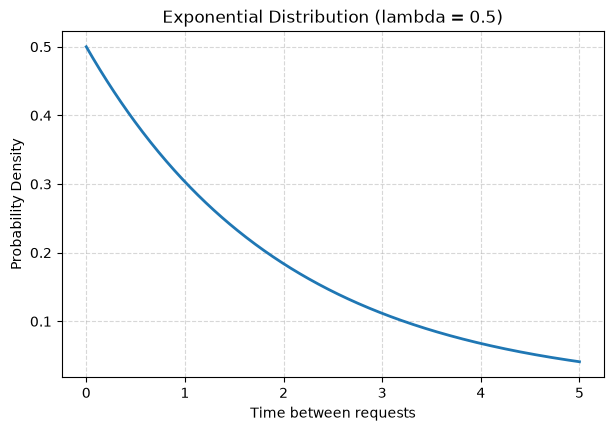

In [37]:
# Define rate parameter (lambda) and mean scale (1 / lambda)
rate_lambda = 0.5  # 0.5 tickets per minute
scale = 1 / rate_lambda  # 2 minutes average wait time
# Generate time values (x-axis)
x = np.linspace(0, 5, 500)
# Compute Exponential PDF
y = expon.pdf(x, scale=scale)
# Plot the distribution
plt.figure(figsize=(7, 4.5))
plt.plot(x, y, linewidth=2)
plt.xlabel("Time between requests")
plt.ylabel("Probability Density")
plt.title("Exponential Distribution (lambda = 0.5)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Example: exponential distribution ($\lambda\ = 0.5, 1.0, 1.5$)

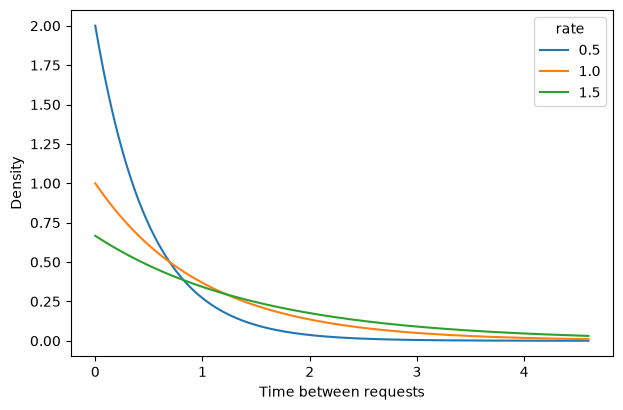

In [38]:
evenly_spaced_values = np.linspace(0, 4.6, 500)
x = evenly_spaced_values
rates = [0.5, 1.0, 1.5]
records = []
for rate in rates:
    y = (1 / rate) * np.exp(-x / rate)
    for xi, yi in zip(x, y):
        records.append(
            {"Time between requests": xi, "density": yi, "rate": str(rate)}
        )
df = pd.DataFrame(records)
plt.figure(figsize=(7, 4.5))
sns.lineplot(data=df, x="Time between requests", y="density", hue="rate")
plt.ylabel("Density")
plt.show()

### Examples: How long until a new request is created?

#### Expected value of exponential distribution

In terms of rate (Poisson):
- $\lambda = 0.5\text{ requests per minute}$
In terms of time between events (exponential):
- $1/\lambda = 1\text{ request per } 2\text{ minutes}$
- $1/0.5 = 2$

### Using `expon.cdf`

In [39]:
# P(wait < 1 min)
# scale = 1/λ = 1/0.5 = 2
expon.cdf(1, scale=2)

np.float64(0.3934693402873666)

In [40]:
# P(wait > 4 min)
1 - expon.cdf(4, scale=2)

np.float64(0.1353352832366127)

In [41]:
# P(1 min < wait < 4 min)
expon.cdf(4, scale=2) - expon.cdf(1, scale=2)

np.float64(0.4711953764760207)

## t-distribution (Student t-distribution)


### Definition

The Student's t-distribution is a continuous probability distribution that resembles the standard normal distribution (bell-shaped and symmetric around zero), but with heavier, flatter tails.

Statistical inference when:
1. The sample size is small (typically $n<30$).
1. The population standard deviation ($σ$) is unknown and must be estimated using the sample standard deviation ($s$).

The shape of the t-distribution is controlled by its degrees of freedom ($df$), which is defined as $df=n-1$ for single-sample problems:

Lower degrees of freedom:
- **Lower peak and wider**, heavier tails, reflecting greater uncertainty due to smaller sample sizes.
- **Higher degrees** of freedom: As $df$ increases towards infinity, the t-distribution converges directly to the standard normal distribution ($N(0,1)$).

### Mathematical Representation

#### Probability Density Function (PDF)
The probability density function (PDF) of a t-distribution with $\nu$ degrees of freedom is expressed as:

<br>

$$
f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu \pi} \, \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu + 1}{2}}
$$

<br>

#### Sample t-Score Statistic Formula

<br>

$$
t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}
$$

<br>

#### Mean and Variance Properties

<br>

$$
\text{Mean: } \mathbb{E}[T] = 0 \quad (\text{for } \nu > 1)
$$

<br>

$$
\text{Variance: } \text{Var}(T) = \frac{\nu}{\nu - 2} \quad (\text{for } \nu > 2)
$$

### Standard distribution vs t-distribution

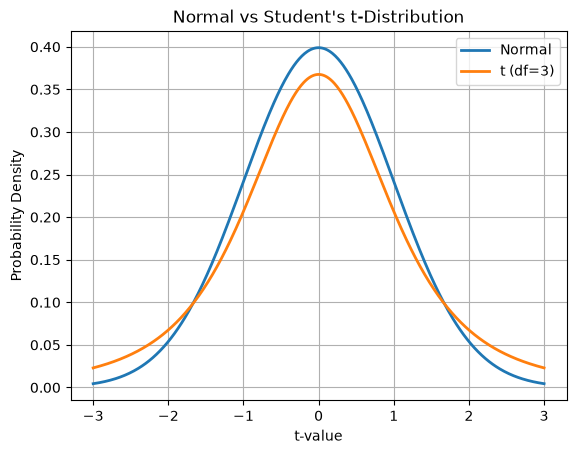

In [42]:
# Define range of t-values
x = np.linspace(-3, 3, 500)

# Plot standard normal distribution
plt.plot(x, norm.pdf(x), label='Normal', linewidth=2)

# Plot t-distribution with df=3
plt.plot(x, t.pdf(x, df=3), label='t (df=3)', linewidth=2)

plt.title("Normal vs Student's t-Distribution")
plt.xlabel("t-value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

### t-distribution - degrees of freedom

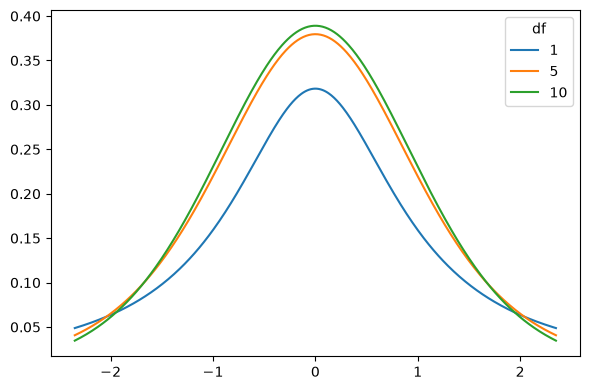

In [43]:
# Define range matching x-axis bounds (-2.35 to 2.35)
x = np.linspace(-2.35, 2.35, 500)

# Degrees of freedom to compare
df_values = [1, 5, 10]

# Create figure
plt.figure(figsize=(6, 4))

# Plot PDF for each degree of freedom
for df in df_values:
    y = t.pdf(x, df=df)
    plt.plot(x, y, label=str(df))

# Set legend with title
plt.legend(title='df', loc='upper right')

# Display plot
plt.tight_layout()
plt.show()

Has parameter degrees of freedom (df) which affects the thickness of the tails
- Lower df = thicker tails, higher standard deviation
- Higher df = closer to normal distribution

## Log-normal distributions

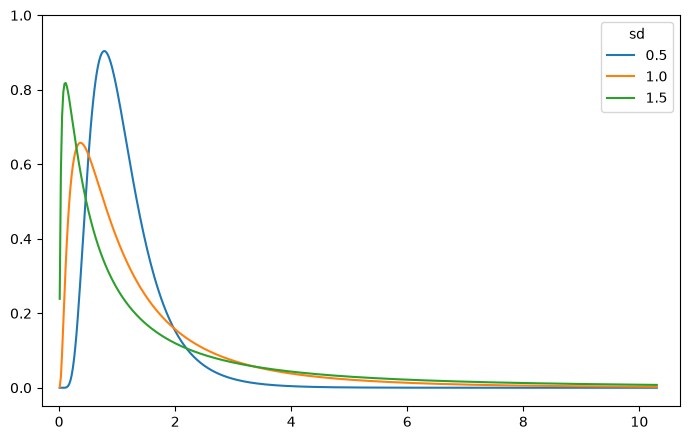

In [44]:
# Generate x values from near 0 to 10.3
x = np.linspace(0.01, 10.3, 500)
sds = [0.5, 1.0, 1.5]

plt.figure(figsize=(7, 4.5))

for sd in sds:
  # 's' parameter corresponds to the standard deviation (sd) of log(X)
  # scale = exp(mu); when mu = 0, scale = exp(0) = 1
  pdf = lognorm.pdf(x, s=sd, scale=np.exp(0))
  plt.plot(x, pdf, label=f'{sd}')

plt.legend(title='sd')
plt.xlim(-0.3, 10.7)
plt.ylim(-0.05, 1.0)
plt.tight_layout()
plt.show()

### Probability density

<br>

$$
f(x; \mu, \sigma) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right), \quad x > 0
$$

<br>

### Real Life Scenarios

Variable whose logarithm is normally distributed

Examples:
- Length of chess games
- Adult blood pressure
- Number of hospitalizations in the 2003 SARS outbreak